
# Predicción de Avalúos Catastrales
**Proyecto de Analítica Predictiva (CRISP-DM)**

**Integrantes:** Juan Sebastián Sánchez Hincapié

---

## 1. Entendimiento del negocio

### 1.1 Descripción del Problema

El avalúo catastral es un valor económico asignado a cada predio que sirve como base para el cálculo de impuestos y procesos de planeación territorial.
Actualmente, la estimación de este valor depende de múltiples variables físicas, económicas y de localización del predio.

El problema consiste en **predecir el avalúo catastral (`AVALUO`) de un predio urbano a partir de sus características registradas en el catastro**, utilizando técnicas de analítica predictiva.

Esto permitirá a las entidades públicas mejorar la estimación de avalúos, validar información y apoyar la planeación fiscal.

---

### 1.2 Diseño de Solución

- **Tipo de análisis:** Predictivo
- **Tipo de aprendizaje:** Supervisado (Regresión)
- **Método elegido:** Random Forest (Regresión)

**Justificación:**
Random Forest es un modelo de ensamble basado en árboles de decisión.
Se adapta bien a datos heterogéneos con variables numéricas y categóricas, maneja outliers y es capaz de capturar relaciones no lineales entre variables.
Estas características lo hacen ideal para la predicción de avalúos catastrales, donde los valores pueden variar significativamente según ubicación, área y destino económico.

**Métricas de evaluación:**

- **MAE** (Mean Absolute Error): para interpretar el error medio en pesos colombianos.
- **RMSE** (Root Mean Squared Error): para evaluar el impacto de errores grandes en avalúos altos.
- **MAPE** (Mean Absolute Percentage Error): para medir el porcentaje de error relativo al valor real del predio.

---

## 2. Entendimiento de los datos

### Diccionario de datos

---

### 2.1 Variable dependiente

La variable que se desea predecir, desconocida en el futuro.

| Variable | Descripción                                                                             |
| -------- | --------------------------------------------------------------------------------------- |
| AVALUO   | Valor catastral total del predio (suma del valor del terreno, construcciones y anexos). |

---

### 2.2 Variables independientes

Variables conocidas en el futuro, que permiten hacer la predicción de la variable dependiente.

| Variable          | Descripción                                                                               |
| ----------------- | ----------------------------------------------------------------------------------------- |
| AREA_CONSTRUCCION | Área construida del predio (en m²).                                                       |
| AREA_TERRENO      | Área total del terreno (en m²).                                                           |
| VALOR_TERR        | Valor monetario asignado al terreno.                                                      |
| VALOR_CONST       | Valor monetario asignado a las construcciones.                                            |
| DESTINO_ECONOMICO | Clasificación del uso económico del predio (residencial, comercial, institucional, etc.). |
| COMUNA            | Identificador de la comuna donde se ubica el predio.                                      |
| BARRIO            | Identificador o nombre del barrio donde se encuentra el predio.                           |
| AREA_ANEXO        | Área de construcciones anexas (garajes, depósitos, etc.).                                 |
| VALOR_ANEXO       | Valor monetario de las construcciones anexas.                                             |

---

### 2.3 Reglas de calidad

#### Variables numéricas

| Variable          | Valor mínimo\* | Valor máximo\* |
| ----------------- | -------------- | -------------- |
| AREA_CONSTRUCCION | 0 m²           | 2,000 m²       |
| AREA_TERRENO      | 1 m²           | 50,000 m²      |
| VALOR_TERR        | 100,000        | 5,000,000,000  |
| VALOR_CONST       | 0              | 5,000,000,000  |
| VALOR_ANEXO       | 0              | 500,000,000    |
| AVALUO            | 100,000        | 10,000,000,000 |

\*Valores definidos según entendimiento del negocio y rangos realistas para predios urbanos.

---

#### Variables categóricas

| Variable          | Valores posibles                                                 |
| ----------------- | ---------------------------------------------------------------- |
| DESTINO_ECONOMICO | {Residencial, Comercial, Industrial, Institucional, Mixto, Otro} |
| COMUNA            | Códigos numéricos (0001 – 0065)                                  |
| BARRIO            | Identificador o nombre de barrio (00-99)                         |

---

## 3. Preparación de datos

### Carga de datos y exploración inicial

In [67]:

import pandas as pd

# Cargar dataset
df = pd.read_excel('../data/historicos_2022.xlsx')

# Vista rápida
df.head()


,ID_PREDIO,NUMERO_PREDIAL_NACIONAL,COMUNA,BARRIO,MANZANA,TERRENO,PREDIO,VIGENCIA,DESCRIP_CONDICION_PROPIEDAD,ID_TERRENO,AREA_CONSTRUCCION,AREA_TERRENO,VALOR_TERR,VALOR_CONST,DESTINO_ECONOMICO,AVALUO,AREA_ANEXO,VALOR_ANEXO
0,885102,760010100177400690001903990475,17,74,69,1,475,2022-01-01,PH,1.774007e+11,12,4.0,3127957.56,7596468.36,411,10724425.92,0.0,0.00
1,915228,760010100177500980020901050102,17,75,98,20,102,2022-01-01,PH,1.775010e+11,55,36.0,28285291.44,58093902.18,2,86379193.62,0.0,0.00
2,2237,760010100021700870001000000001,2,17,87,1,1,2022-01-01,NPH,2.170087e+10,0,247.0,30493338.37,0.00,0,30493338.37,0.0,0.00
3,2239,760010100021700840001000000001,2,17,84,1,1,2022-01-01,NPH,2.170084e+10,0,147.0,18147857.25,0.00,0,18147857.25,0.0,0.00
4,9969,760010000560000030002500000003,56,0,3,2,3,2022-01-01,MEJORAS POR EDIFICACIONES EN TERRENO AJENO DE ...,5.600030e+09,250,0.0,0.00,48940140.93,1003,52008719.54,86.0,3068578.61


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750068 entries, 0 to 750067
Data columns (total 18 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   ID_PREDIO                    750068 non-null  int64         
 1   NUMERO_PREDIAL_NACIONAL      750068 non-null  object        
 2   COMUNA                       750068 non-null  int64         
 3   BARRIO                       750068 non-null  int64         
 4   MANZANA                      750068 non-null  int64         
 5   TERRENO                      750068 non-null  int64         
 6   PREDIO                       750068 non-null  int64         
 7   VIGENCIA                     750068 non-null  datetime64[ns]
 8   DESCRIP_CONDICION_PROPIEDAD  750068 non-null  object        
 9   ID_TERRENO                   750018 non-null  float64       
 10  AREA_CONSTRUCCION            750068 non-null  int64         
 11  AREA_TERRENO              

## 3.1 Selección de variables


Desde el conocimiento del negocio, seleccionamos las variables relevantes para predecir el **avalúo total (AVALUO)**:

- **Área Construcción (AREA_CONSTRUCCION)**
- **Área Terreno (AREA_TERRENO)**
- **Valor Terreno (VALOR_TERR)**
- **Valor Construcción (VALOR_CONST)**
- **Destino Económico (DESTINO_ECONOMICO)**
- **Comuna (COMUNA)**
- **Barrio (BARRIO)**
- **Área Anexo (AREA_ANEXO)**
- **Valor Anexo (VALOR_ANEXO)**


## 3.2 Descripción estadística

In [69]:
cols_a_dropear = [
    'NUMERO_PREDIAL_NACIONAL', 'TERRENO', 'PREDIO',
    'ID_TERRENO', 'MANZANA', 'DESCRIP_CONDICION_PROPIEDAD', 'VIGENCIA'
]

df = df.drop(columns=cols_a_dropear)

df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID_PREDIO,750068.0,NaN,NaN,NaN,500204.269053,295781.279473,1.0,237841.75,495847.5,756417.25,1010589.0
COMUNA,750068.0,NaN,NaN,NaN,15.968968,14.08601,1.0,6.0,15.0,19.0,65.0
BARRIO,750068.0,NaN,NaN,NaN,35.131091,40.486357,0.0,3.0,10.0,84.0,99.0
AREA_CONSTRUCCION,750068.0,NaN,NaN,NaN,105.738988,529.678221,0.0,22.0,63.0,123.0,261113.0
AREA_TERRENO,750068.0,NaN,NaN,NaN,707.369826,46058.154699,0.0,12.0,52.0,105.0,26264686.0
VALOR_TERR,750068.0,NaN,NaN,NaN,49105279.109629,743915619.086945,0.0,5529516.49,16971174.86,35349930.63,427414277562.73999
VALOR_CONST,750068.0,NaN,NaN,NaN,63905927.042728,442954652.474696,-929267342.94,7632538.96,31299499.3,69576243.3425,193601316400.170013
DESTINO_ECONOMICO,750068,1264,3,244025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AVALUO,750068.0,NaN,NaN,NaN,114016403.092402,1083046342.83265,251.93,16034399.475,55382268.21,109164552.05,629728560513.719971
AREA_ANEXO,750068.0,NaN,NaN,NaN,8.231801,353.721143,0.0,0.0,0.0,0.0,196208.0


## 3.3 Limpieza de atípicos

In [77]:
df = df[df['AREA_CONSTRUCCION'] > 0]
df = df[df['AREA_TERRENO'] > 0]
float_cols = ['AREA_TERRENO','VALOR_TERR','VALOR_CONST','AVALUO','AREA_ANEXO','VALOR_ANEXO']
df = df[(df[float_cols] >= 0).all(axis=1)]

df.head()

,ID_PREDIO,COMUNA,BARRIO,AREA_CONSTRUCCION,AREA_TERRENO,VALOR_TERR,VALOR_CONST,DESTINO_ECONOMICO,AVALUO,AREA_ANEXO,VALOR_ANEXO,AREA_TOTAL,VALOR_TOTAL_CONSTRUCCION,RATIO_VALOR_POR_M2
8,17449,54,0,151,652.0,3.256975e+07,3.464362e+07,"1003,1003",7.381438e+07,91.0,6601012.11,242.0,4.124463e+07,113038.871485
9,17949,54,0,661,7364.0,3.985132e+08,2.092361e+08,"1003,1003",6.143075e+08,152.0,6558194.72,813.0,2.157943e+08,83409.031050
11,18365,54,0,809,6724.0,3.638787e+08,3.417770e+08,"1003,1003,1003",7.285487e+08,125.0,22893023.63,934.0,3.646700e+08,108334.384104
12,18453,64,0,528,2081.0,1.807880e+08,2.854016e+08,1315,4.661896e+08,0.0,0.00,528.0,2.854016e+08,223914.294995
16,19469,64,0,91,2493.0,1.286818e+08,1.037199e+07,"1003,1315",1.390537e+08,0.0,0.00,91.0,1.037199e+07,55755.311047


## 3.4 Limpieza de nulos

In [78]:
df = df.dropna()

df.isnull().mean() * 100



ID_PREDIO                   0.0
COMUNA                      0.0
BARRIO                      0.0
AREA_CONSTRUCCION           0.0
AREA_TERRENO                0.0
VALOR_TERR                  0.0
VALOR_CONST                 0.0
DESTINO_ECONOMICO           0.0
AVALUO                      0.0
AREA_ANEXO                  0.0
VALOR_ANEXO                 0.0
AREA_TOTAL                  0.0
VALOR_TOTAL_CONSTRUCCION    0.0
RATIO_VALOR_POR_M2          0.0
dtype: float64

## 3.5 Creación de nuevas variables

In [80]:
# Área total (construcción + anexos)
df['AREA_TOTAL'] = df['AREA_CONSTRUCCION'] + df['AREA_ANEXO']

# Valor total de construcción (valor construcción + valor anexos)
df['VALOR_TOTAL_CONSTRUCCION'] = df['VALOR_CONST'] + df['VALOR_ANEXO']

# Relación entre avalúo y área de terreno (valor por m2)
df['RATIO_VALOR_POR_M2'] = df['AVALUO'] / (df['AREA_TERRENO'])


# Reglas de calidad adicionales

# Eliminar registros en donde el área de construcción supere al área de terreno
df = df[df['AREA_TERRENO'] > df['AREA_CONSTRUCCION']]


# Visualizar nuevas variables

df[['AREA_CONSTRUCCION',
    'AREA_ANEXO',
    'AREA_TOTAL',
    'VALOR_CONST',
    'VALOR_ANEXO',
    'VALOR_TOTAL_CONSTRUCCION',
    'AREA_TERRENO',
    'AVALUO',
    'RATIO_VALOR_POR_M2']].head()



,AREA_CONSTRUCCION,AREA_ANEXO,AREA_TOTAL,VALOR_CONST,VALOR_ANEXO,VALOR_TOTAL_CONSTRUCCION,AREA_TERRENO,AVALUO,RATIO_VALOR_POR_M2
8,151,91.0,242.0,3.464362e+07,6601012.11,4.124463e+07,652.0,7.381438e+07,113212.243988
9,661,152.0,813.0,2.092361e+08,6558194.72,2.157943e+08,7364.0,6.143075e+08,83420.357643
11,809,125.0,934.0,3.417770e+08,22893023.63,3.646700e+08,6724.0,7.285487e+08,108350.495702
12,528,0.0,528.0,2.854016e+08,0.00,2.854016e+08,2081.0,4.661896e+08,224021.894368
16,91,0.0,91.0,1.037199e+07,0.00,1.037199e+07,2493.0,1.390537e+08,55777.675792


#### Multi-label One-Hot Encoding

In [84]:
# Separar por coma y expandir
destinos = df['DESTINO_ECONOMICO'].astype(str).str.get_dummies(sep=',')
# Renombrar columnas para mayor claridad
destinos = destinos.add_prefix("DE_")
# Unir al dataframe
df_encoded = pd.concat([df, destinos], axis=1)

df_encoded.head()



,ID_PREDIO,COMUNA,BARRIO,AREA_CONSTRUCCION,AREA_TERRENO,VALOR_TERR,VALOR_CONST,DESTINO_ECONOMICO,AVALUO,AREA_ANEXO,...,DE_412,DE_413,DE_414,DE_415,DE_416,DE_5,DE_511,DE_611,DE_712,DE_713
8,17449,54,0,151,652.0,3.256975e+07,3.464362e+07,"1003,1003",7.381438e+07,91.0,...,0,0,0,0,0,0,0,0,0,0
9,17949,54,0,661,7364.0,3.985132e+08,2.092361e+08,"1003,1003",6.143075e+08,152.0,...,0,0,0,0,0,0,0,0,0,0
11,18365,54,0,809,6724.0,3.638787e+08,3.417770e+08,"1003,1003,1003",7.285487e+08,125.0,...,0,0,0,0,0,0,0,0,0,0
12,18453,64,0,528,2081.0,1.807880e+08,2.854016e+08,1315,4.661896e+08,0.0,...,0,0,0,0,0,0,0,0,0,0
16,19469,64,0,91,2493.0,1.286818e+08,1.037199e+07,"1003,1315",1.390537e+08,0.0,...,0,0,0,0,0,0,0,0,0,0


## 3.6 Análisis de relaciones

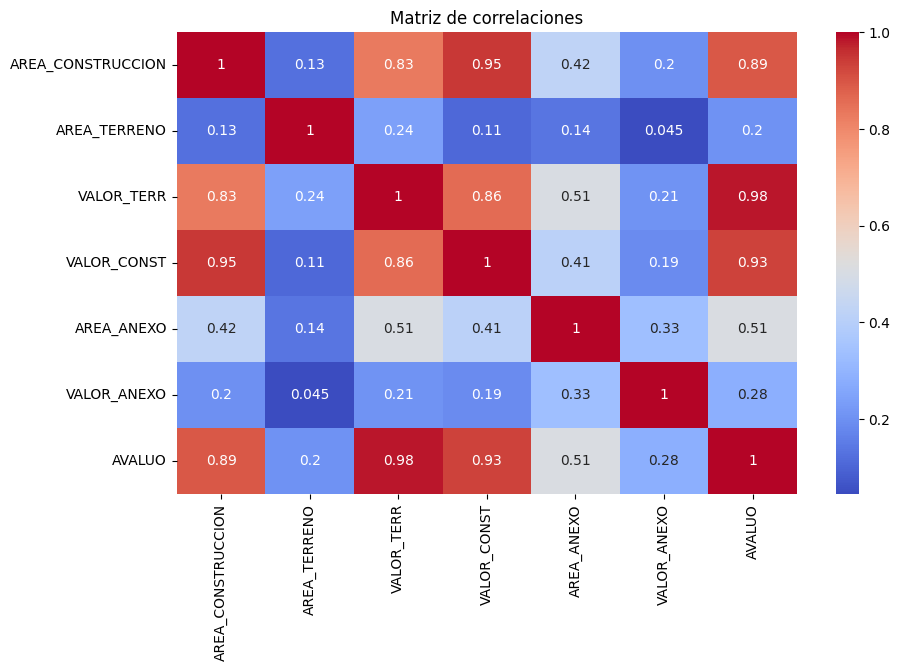

In [85]:

import seaborn as sns
import matplotlib.pyplot as plt

# Matriz de correlaciones
plt.figure(figsize=(10,6))
sns.heatmap(df[['AREA_CONSTRUCCION','AREA_TERRENO','VALOR_TERR','VALOR_CONST',
                'AREA_ANEXO','VALOR_ANEXO','AVALUO']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlaciones')
plt.show()


## 4. Modelamiento y evaluación

### 4.1 Configuración y selección de métodos de machine learning


#### 4.1.1 Selección de 5 modelos de Machine Learning clásico

In [60]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Definir modelos clásicos
modelos_clasicos = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

modelos_clasicos

{'LinearRegression': LinearRegression(),
 'Ridge': Ridge(),
 'DecisionTree': DecisionTreeRegressor(random_state=42),
 'KNN': KNeighborsRegressor(),
 'SVR': SVR()}

#### 4.1.2 Selección de 3 modelos de Ensambles

In [61]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor

# Ensambles
modelos_ensamble = {
    "RandomForest (Bagging)": RandomForestRegressor(random_state=42),
    "GradientBoosting (Boosting)": GradientBoostingRegressor(random_state=42),
    "VotingRegressor (Promedio)": VotingRegressor([
        ('lr', LinearRegression()),
        ('rf', RandomForestRegressor(random_state=42)),
        ('gbr', GradientBoostingRegressor(random_state=42))
    ])
}

modelos_ensamble


{'RandomForest (Bagging)': RandomForestRegressor(random_state=42),
 'GradientBoosting (Boosting)': GradientBoostingRegressor(random_state=42),
 'VotingRegressor (Promedio)': VotingRegressor(estimators=[('lr', LinearRegression()),
                             ('rf', RandomForestRegressor(random_state=42)),
                             ('gbr',
                              GradientBoostingRegressor(random_state=42))])}

### 4.2 Ajuste de hiperparámetros con el 70% de los datos haciendo cross validation

#### 4.2.1 Justificación de selección de la métrica de desempeño

En este caso usamos **MAE (Mean Absolute Error)** como métrica principal porque:
- Es intuitiva (error promedio en unidades monetarias).
- No penaliza tanto los errores grandes como el RMSE, lo que la hace más estable con outliers.
- Se interpreta directamente como el error medio en pesos colombianos.

Como métricas secundarias se evaluarán **RMSE** y **MAPE**.


#### 4.2.2 Ajuste de hiperparámetros de modelos clásicos

                     feature  importance
4                 VALOR_TERR    0.477421
8                 AREA_TOTAL    0.237472
2          AREA_CONSTRUCCION    0.105043
9   VALOR_TOTAL_CONSTRUCCION    0.093833
5                VALOR_CONST    0.064421
72                    DE_320    0.009898
7                VALOR_ANEXO    0.003196
6                 AREA_ANEXO    0.001520
3               AREA_TERRENO    0.001478
10        RATIO_VALOR_POR_M2    0.001168
1                     BARRIO    0.000843
68                    DE_316    0.000726
0                     COMUNA    0.000459
62                      DE_3    0.000440
67                    DE_315    0.000333
20                    DE_112    0.000296
64                    DE_312    0.000216
61                    DE_214    0.000215
63                    DE_311    0.000177
27                    DE_116    0.000158


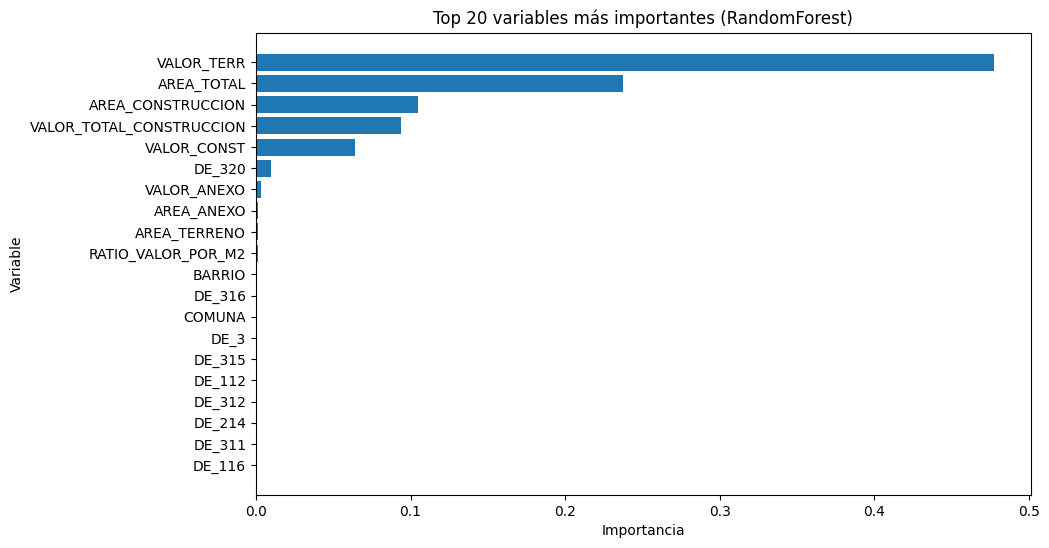

In [ ]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd


# Variables predictoras y target

X = df_encoded.drop(columns=['AVALUO', 'ID_PREDIO'])
y = df_encoded['AVALUO']


# Entrenar un RandomForest rápido

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X, y)


# Importancia de variables

importances = rf.feature_importances_
features = X.columns

# DataFrame ordenado
feat_importances = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Mostrar top 20
print(feat_importances.head(20))


# Visualización

plt.figure(figsize=(10,6))
plt.barh(feat_importances["feature"].head(20), feat_importances["importance"].head(20))
plt.gca().invert_yaxis()
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Top 20 variables más importantes (RandomForest)")
plt.show()


En el proceso de ajuste de modelos se decidió **eliminar la variable `DESTINO_ECONOMICO`**, a pesar de ser categórica y potencialmente informativa. Esta decisión se basó en dos criterios principales:

1. **Simplificación del modelo**  
   - La codificación de `DESTINO_ECONOMICO` mediante *OneHotEncoding* generaba un gran número de variables (`DE_...`), lo que aumentaba la dimensionalidad sin aportar valor significativo al desempeño.  
   - La presencia de muchas categorías con baja frecuencia incrementaba la complejidad del entrenamiento y ocasionaba errores de convergencia en algunos modelos lineales.

2. **Análisis de importancia de variables (RandomForest)**  
   - El análisis de *feature importance* mostró que la contribución conjunta de `DESTINO_ECONOMICO` era mínima (menos del 2% del total).  
   - Solamente una categoría (`DE_320`) tuvo una importancia cercana al 1%, mientras que el resto se ubicaron en valores prácticamente nulos.  
   - En contraste, variables como `VALOR_TERR`, `AREA_TOTAL` y `VALOR_TOTAL_CONSTRUCCION` concentraron más del 80% de la relevancia.

In [94]:
df = df.drop(columns=['DESTINO_ECONOMICO'])

In [95]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

# Split train/test (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==========================
# Definir modelos clásicos
# ==========================
modelos_clasicos = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

# ==========================
# Grids de hiperparámetros
# ==========================
param_grids_clasicos = {
    "Ridge": {"alpha": [0.1, 1, 10]},
    "DecisionTree": {"max_depth": [3, 5, 10, None]},
    "KNN": {"n_neighbors": [3, 5, 10]},
    "SVR": {"C": [0.1, 1, 10], "kernel": ["linear", "rbf"]}
}

# ==========================
# Ajuste de hiperparámetros
# ==========================
best_models_clasicos = {}

for nombre, modelo in modelos_clasicos.items():
    if nombre in param_grids_clasicos:
        grid = GridSearchCV(
            modelo,
            param_grids_clasicos[nombre],
            cv=5,
            scoring="neg_mean_absolute_error",
            n_jobs=-1,
            error_score='raise'
        )
        grid.fit(X_train, y_train)
        best_models_clasicos[nombre] = grid.best_estimator_
        print(f"{nombre}: {grid.best_params_}, MAE={-grid.best_score_:.2f}")
    else:
        # Para modelos sin hiperparámetros complejos (ej: LinearRegression)
        modelo.fit(X_train, y_train)
        best_models_clasicos[nombre] = modelo
        print(f"{nombre}: sin ajuste, entrenado.")


LinearRegression: sin ajuste, entrenado.
Ridge: {'alpha': 10}, MAE=1712773.66
DecisionTree: {'max_depth': None}, MAE=23258028.26
KNN: {'n_neighbors': 3}, MAE=10314299.57


KeyboardInterrupt: 